# FundFit AI — SME Financial Distress Prediction

This notebook explores the SME financial decision dataset and builds an initial machine learning model to predict whether an SME is likely to experience financial distress.

The goal of this notebook is to:
1. Inspect the dataset structure
2. Understand the target variable
3. Perform basic preprocessing
4. Train baseline machine learning models
5. Evaluate model performance
6. Identify which model should be used for the first version of the web app

## 1. Import Libraries

In this section, we import the Python libraries needed for data loading, exploration, visualization, preprocessing, modeling, and evaluation.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load Dataset

The dataset is loaded from the `data/raw/` folder. Each row represents one SME, while the columns describe financial literacy, risk awareness, decision-making behavior, digital finance usage, revenue category, and financial distress status.

In [22]:
df = pd.read_csv("../data/raw/sme_data.csv")

df.head()

,Has_Financial_Questions,SME_Age,SME_Type,Industry_Sector,SME_Size_Category,Literacy_Accounting,Literacy_Budgeting,Literacy_Investment_Evaluation,Literacy_Credit_Knowledge,Risk_Awareness,...,Decision_Capital_Allocation,Decision_CashFlow_Management,Analysis_Accounting_Tools,Analysis_Financial_Ratios,Analysis_Forecasting,Analysis_Benchmarking,Liquidity_Stability,Uses_Digital_Finance,Annual_Revenue_Category,Financial_Distress
0,YES,21.0,3.0,1.0,1.0,3.0,3.0,3.0,6.0,0.0,...,6.0,5.0,3.0,5.0,3.0,5.0,6.0,0.0,2.0,0
1,YES,29.0,2.0,2.0,3.0,2.0,2.0,3.0,2.0,0.0,...,0.0,3.0,2.0,8.0,3.0,5.0,3.0,0.0,2.0,0
2,YES,29.0,2.0,1.0,3.0,3.0,3.0,5.0,5.0,7.0,...,1.0,3.0,3.0,2.0,5.0,5.0,7.0,0.0,4.0,1
3,YES,6.0,2.0,2.0,2.0,4.0,4.0,5.0,6.0,9.0,...,3.0,5.0,4.0,7.0,5.0,5.0,4.0,0.0,2.0,1
4,YES,12.0,2.0,3.0,4.0,3.0,3.0,3.0,6.0,9.0,...,4.0,3.0,3.0,5.0,3.0,5.0,6.0,0.0,2.0,1


### Initial Observation

The first five rows show that the dataset contains SME-level information related to financial behavior, risk awareness, financial decision-making, and business characteristics. The target variable is `Financial_Distress`, which indicates whether the SME is experiencing financial distress.

## 3. Dataset Overview

This section checks the number of rows and columns, column names, data types, and missing values. This helps us understand whether cleaning or preprocessing is needed before modeling.

In [26]:
print("Dataset shape:", df.shape)

Dataset shape: (15106, 33)


### Observation

The dataset contains 15,106 rows and 33 columns. This is a reasonably sized dataset for building a first machine learning model.

In [29]:
df.columns.tolist()

['Has_Financial_Questions',
 'SME_Age',
 'SME_Type',
 'Industry_Sector',
 'SME_Size_Category',
 'Literacy_Accounting',
 'Literacy_Budgeting',
 'Literacy_Investment_Evaluation',
 'Literacy_Credit_Knowledge',
 'Risk_Awareness',
 'Risk_Evaluation',
 'Risk_Mitigation_Strategies',
 'Risk_Taking_Willingness',
 'Assessment_Data_Driven',
 'Assessment_Expert_Consultation',
 'Assessment_Scenario_Analysis',
 'Assessment_Internal_Evaluation',
 'Decision_Autonomy',
 'Decision_Consultation',
 'Decision_Financial_Advisor',
 'Decision_Strategic_Alignment',
 'Decision_Investment_Choices',
 'Decision_Loan_Approval',
 'Decision_Capital_Allocation',
 'Decision_CashFlow_Management',
 'Analysis_Accounting_Tools',
 'Analysis_Financial_Ratios',
 'Analysis_Forecasting',
 'Analysis_Benchmarking',
 'Liquidity_Stability',
 'Uses_Digital_Finance',
 'Annual_Revenue_Category',
 'Financial_Distress']

### Observation

Most columns are numerical features related to SME financial literacy, risk evaluation, decision-making, financial analysis, liquidity stability, digital finance usage, and revenue category. The final column, `Financial_Distress`, will be used as the target variable.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15106 entries, 0 to 15105
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Has_Financial_Questions         15106 non-null  object 
 1   SME_Age                         15106 non-null  float64
 2   SME_Type                        15106 non-null  float64
 3   Industry_Sector                 15106 non-null  float64
 4   SME_Size_Category               15106 non-null  float64
 5   Literacy_Accounting             15106 non-null  float64
 6   Literacy_Budgeting              15106 non-null  float64
 7   Literacy_Investment_Evaluation  15106 non-null  float64
 8   Literacy_Credit_Knowledge       15106 non-null  float64
 9   Risk_Awareness                  15106 non-null  float64
 10  Risk_Evaluation                 15106 non-null  float64
 11  Risk_Mitigation_Strategies      15106 non-null  float64
 12  Risk_Taking_Willingness         

### Observation

Most columns are numeric, while `Has_Financial_Questions` is stored as an object column. This column needs to be encoded before training machine learning models.

## 4. Missing Value Check

Missing values can affect model training. In this section, we check whether any columns contain null values.

In [34]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Has_Financial_Questions           0
Decision_Autonomy                 0
Annual_Revenue_Category           0
Uses_Digital_Finance              0
Liquidity_Stability               0
Analysis_Benchmarking             0
Analysis_Forecasting              0
Analysis_Financial_Ratios         0
Analysis_Accounting_Tools         0
Decision_CashFlow_Management      0
Decision_Capital_Allocation       0
Decision_Loan_Approval            0
Decision_Investment_Choices       0
Decision_Strategic_Alignment      0
Decision_Financial_Advisor        0
Decision_Consultation             0
Assessment_Internal_Evaluation    0
SME_Age                           0
Assessment_Scenario_Analysis      0
Assessment_Expert_Consultation    0
Assessment_Data_Driven            0
Risk_Taking_Willingness           0
Risk_Mitigation_Strategies        0
Risk_Evaluation                   0
Risk_Awareness                    0
Literacy_Credit_Knowledge         0
Literacy_Investment_Evaluation    0
Literacy_Budgeting          

### Observation

The dataset does not contain missing values. Therefore, no imputation is required at this stage.

## 5. Target Variable Analysis

The target variable for this project is `Financial_Distress`.

This is a binary classification task:

- `0` = SME is not financially distressed
- `1` = SME is financially distressed

Before training the model, we check whether the target classes are balanced.

In [40]:
df["Financial_Distress"].value_counts()

Financial_Distress
0    10000
1     5106
Name: count, dtype: int64

In [42]:
df["Financial_Distress"].value_counts(normalize=True) * 100

Financial_Distress
0    66.198861
1    33.801139
Name: proportion, dtype: float64

### Observation

The percentage distribution helps us understand whether the dataset is balanced or imbalanced. For a financial risk project, detecting distressed SMEs correctly is important, so recall for class `1` will be especially important.

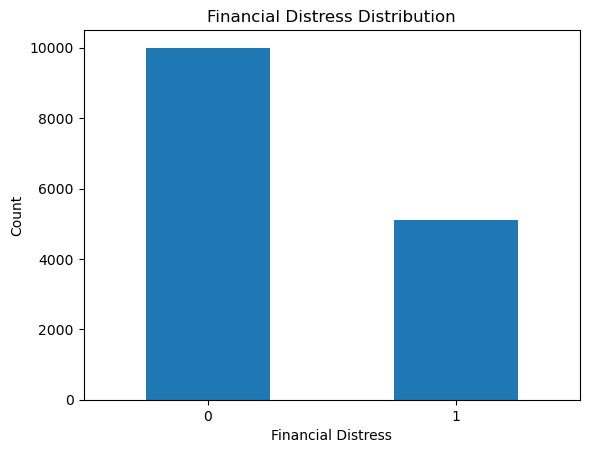

In [45]:
df["Financial_Distress"].value_counts().plot(kind="bar")

plt.title("Financial Distress Distribution")
plt.xlabel("Financial Distress")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Observation

The target variable is not perfectly balanced. There are more SMEs labeled as `0` meaning not financially distressed, compared to SMEs labeled as `1` meaning financially distressed.

However, class `1` still has a large number of samples, so the model should still have enough data to learn patterns for financially distressed SMEs.

Because the goal of this project is to detect financial risk, accuracy alone is not enough. During model evaluation, recall and F1-score for class `1` should be prioritized because class `1` represents SMEs that may need financial attention.

## 6. Basic Feature Analysis

This section explores several important features that may be related to SME financial distress. We compare the average values of selected financial behavior and business indicators between distressed and non-distressed SMEs.

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SME_Age,15106.0,14.250213,8.248664,1.0,7.000000,14.000000,21.0,29.0
SME_Type,15106.0,2.552398,0.938726,1.0,2.000000,2.600485,3.0,4.0
Industry_Sector,15106.0,2.987768,1.111138,1.0,2.000000,3.000000,4.0,5.0
SME_Size_Category,15106.0,2.759196,1.041669,1.0,2.000000,3.000000,3.0,5.0
Literacy_Accounting,15106.0,3.185667,0.963658,0.0,3.000000,3.000000,4.0,10.0
Literacy_Budgeting,15106.0,3.188818,0.887659,1.0,3.000000,3.000000,4.0,5.0
Literacy_Investment_Evaluation,15106.0,4.060329,0.866348,2.0,3.000000,4.000000,5.0,5.0
Literacy_Credit_Knowledge,15106.0,4.448019,2.817387,0.0,2.000000,4.180883,7.0,9.0
Risk_Awareness,15106.0,4.261796,2.799492,0.0,2.000000,4.000000,7.0,9.0
Risk_Evaluation,15106.0,2.199486,1.203449,0.0,1.000000,2.000000,3.0,10.0


In [51]:
df.groupby("Financial_Distress")["Liquidity_Stability"].mean()

Financial_Distress
0    2.466298
1    6.463181
Name: Liquidity_Stability, dtype: float64

### Observation

The average `Liquidity_Stability` value is higher for SMEs labeled as financially distressed compared to non-distressed SMEs. This result is somewhat counterintuitive because financial distress is usually expected to be associated with weaker liquidity stability.

This may indicate that the variable is encoded in a way where a higher value represents greater liquidity risk or instability, rather than better liquidity condition. Therefore, the column should be interpreted carefully. Despite this, the large difference between the two groups suggests that `Liquidity_Stability` is likely an important predictor for financial distress.

In [54]:
df.groupby("Financial_Distress")["Uses_Digital_Finance"].mean()

Financial_Distress
0    0.612317
1    0.614179
Name: Uses_Digital_Finance, dtype: float64

In [56]:
df.groupby("Financial_Distress")["Annual_Revenue_Category"].mean()

Financial_Distress
0    1.768399
1    2.214845
Name: Annual_Revenue_Category, dtype: float64

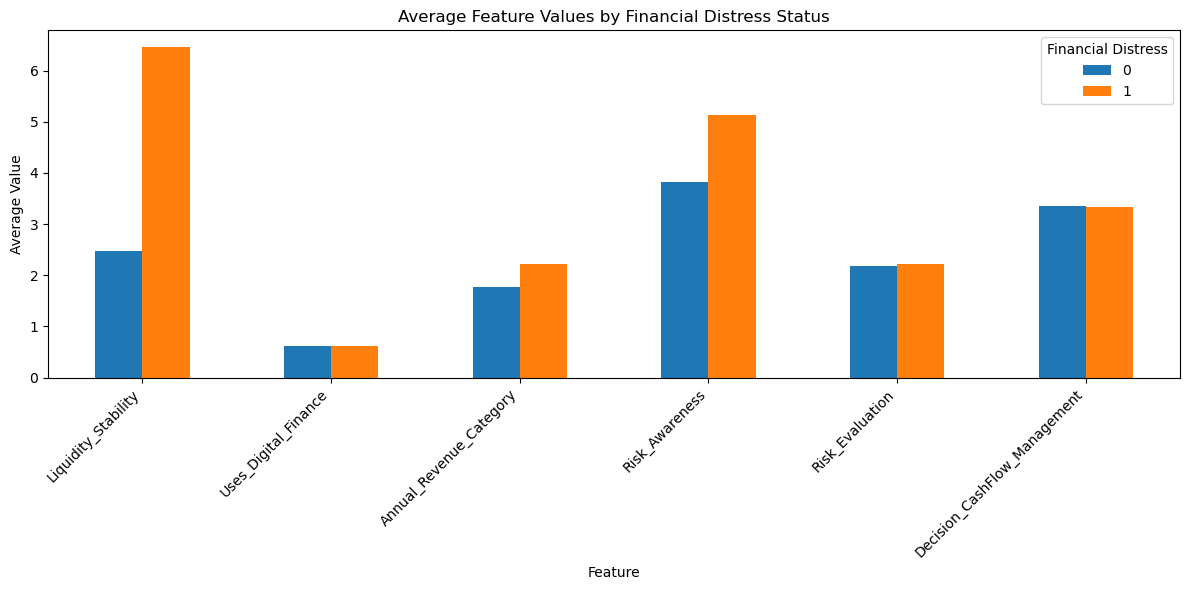

In [58]:
important_features = [
    "Liquidity_Stability",
    "Uses_Digital_Finance",
    "Annual_Revenue_Category",
    "Risk_Awareness",
    "Risk_Evaluation",
    "Decision_CashFlow_Management"
]

grouped_means = df.groupby("Financial_Distress")[important_features].mean().T

grouped_means.plot(kind="bar", figsize=(12, 6))

plt.title("Average Feature Values by Financial Distress Status")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Financial Distress")
plt.tight_layout()
plt.show()

### Observation

The chart shows that several features differ between financially distressed and non-distressed SMEs. `Liquidity_Stability` shows the largest difference, with distressed SMEs having a much higher average value. This suggests that the column may represent liquidity risk or instability rather than positive liquidity condition.

`Risk_Awareness` and `Annual_Revenue_Category` are also higher for distressed SMEs, while `Uses_Digital_Finance`, `Risk_Evaluation`, and `Decision_CashFlow_Management` show smaller differences between the two groups.

Overall, the chart suggests that liquidity-related indicators, risk awareness, and revenue category may be useful predictors for financial distress.

## 7. Prepare Features and Target

The dataset is separated into input features and the target variable.

- `X` contains all predictor variables.
- `y` contains the target variable, `Financial_Distress`.

This prepares the data for machine learning model training.

In [62]:
X = df.drop(columns=["Financial_Distress"])
y = df["Financial_Distress"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15106, 32)
y shape: (15106,)


### Observation

The feature matrix `X` contains all columns except `Financial_Distress`, while `y` contains the binary target label. This means the model will use the SME financial, behavioral, and business indicators to predict whether an SME is financially distressed.

## 8. Encode Categorical Variables

Machine learning models require numerical input. The column `Has_Financial_Questions` is categorical, so it needs to be converted into numerical format before model training.

In [66]:
X["Has_Financial_Questions"].value_counts()

Has_Financial_Questions
YES    15106
Name: count, dtype: int64

In [68]:
X = pd.get_dummies(
    X,
    columns=["Has_Financial_Questions"],
    drop_first=True
)

X.head()

,SME_Age,SME_Type,Industry_Sector,SME_Size_Category,Literacy_Accounting,Literacy_Budgeting,Literacy_Investment_Evaluation,Literacy_Credit_Knowledge,Risk_Awareness,Risk_Evaluation,...,Decision_Loan_Approval,Decision_Capital_Allocation,Decision_CashFlow_Management,Analysis_Accounting_Tools,Analysis_Financial_Ratios,Analysis_Forecasting,Analysis_Benchmarking,Liquidity_Stability,Uses_Digital_Finance,Annual_Revenue_Category
0,21.0,3.0,1.0,1.0,3.0,3.0,3.0,6.0,0.0,3.0,...,5.0,6.0,5.0,3.0,5.0,3.0,5.0,6.0,0.0,2.0
1,29.0,2.0,2.0,3.0,2.0,2.0,3.0,2.0,0.0,3.0,...,1.0,0.0,3.0,2.0,8.0,3.0,5.0,3.0,0.0,2.0
2,29.0,2.0,1.0,3.0,3.0,3.0,5.0,5.0,7.0,1.0,...,3.0,1.0,3.0,3.0,2.0,5.0,5.0,7.0,0.0,4.0
3,6.0,2.0,2.0,2.0,4.0,4.0,5.0,6.0,9.0,1.0,...,4.0,3.0,5.0,4.0,7.0,5.0,5.0,4.0,0.0,2.0
4,12.0,2.0,3.0,4.0,3.0,3.0,3.0,6.0,9.0,3.0,...,3.0,4.0,3.0,3.0,5.0,3.0,5.0,6.0,0.0,2.0


In [70]:
X.shape

(15106, 31)

### Observation

The categorical column has been converted into a numeric dummy variable using one-hot encoding. The feature dataset is now fully numeric and ready for train-test splitting.

## 9. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% of the data is used for testing.

The `stratify=y` option is used to keep the same class distribution of `Financial_Distress` in both the training and testing sets.

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (12084, 31)
Testing features: (3022, 31)
Training target: (12084,)
Testing target: (3022,)


## 10. Baseline Model — Logistic Regression

Logistic Regression is used as the baseline model because it is simple, interpretable, and commonly used for binary classification problems.

The baseline model gives an initial performance benchmark before testing more complex models.

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

log_reg_model = LogisticRegression(max_iter=1000)

log_reg_model.fit(X_train, y_train)

y_pred_log = log_reg_model.predict(X_test)

### 10.1 Logistic Regression Evaluation

The model is evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

In [80]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.9616148246194574

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2001
           1       0.95      0.94      0.94      1021

    accuracy                           0.96      3022
   macro avg       0.96      0.96      0.96      3022
weighted avg       0.96      0.96      0.96      3022



### Observation

The Logistic Regression baseline achieved an accuracy of approximately **96.16%**, which is strong for an initial model.

For class `0` non-distressed SMEs, the model achieved precision, recall, and F1-score of around **0.97**. For class `1` financially distressed SMEs, the model achieved precision of **0.95**, recall of **0.94**, and F1-score of **0.94**.

This is important because class `1` represents SMEs experiencing financial distress. A recall of **0.94** means the model correctly identifies most financially distressed SMEs. Since this project focuses on financial risk detection, this is a good baseline result.

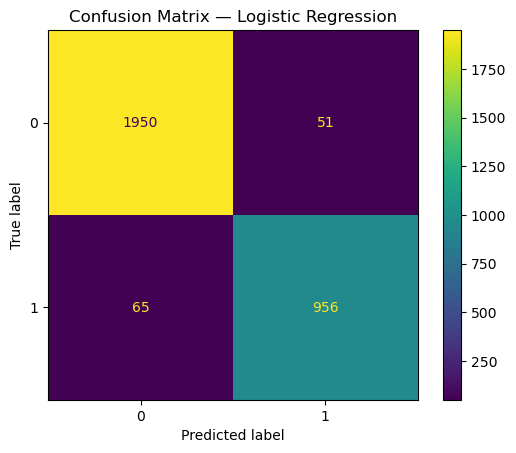

In [83]:
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=log_reg_model.classes_
)

disp.plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

### Observation

The Logistic Regression confusion matrix shows strong performance.

- **1950** non-distressed SMEs were correctly predicted as non-distressed.
- **956** financially distressed SMEs were correctly predicted as distressed.
- **51** non-distressed SMEs were incorrectly predicted as distressed.
- **65** financially distressed SMEs were incorrectly predicted as non-distressed.

The most important error in this project is the **65 false negatives**, because these are financially distressed SMEs that the model failed to detect. However, compared to the total number of distressed SMEs in the test set, the model still captures most distress cases.

Overall, Logistic Regression is a strong baseline model, but we will compare it with Random Forest to see whether a more flexible model can reduce false negatives or improve class `1` performance.

## 11. Stronger Model — Random Forest

Random Forest is tested as a stronger model because it can capture non-linear relationships between features.

Unlike Logistic Regression, Random Forest can learn more complex interactions between SME financial literacy, risk behavior, decision-making patterns, digital finance usage, liquidity stability, and revenue category.

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [89]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9447385837193911

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2001
           1       0.94      0.89      0.92      1021

    accuracy                           0.94      3022
   macro avg       0.94      0.93      0.94      3022
weighted avg       0.94      0.94      0.94      3022



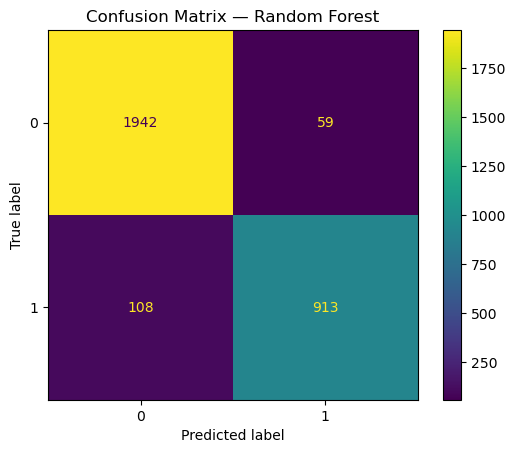

In [91]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("Confusion Matrix — Random Forest")
plt.show()

### Observation

The Random Forest model achieved an accuracy of approximately **94.47%**, which is lower than the Logistic Regression baseline.

For class `1`, which represents financially distressed SMEs, Random Forest achieved:

- Precision: **0.94**
- Recall: **0.89**
- F1-score: **0.92**

The recall for class `1` is lower than Logistic Regression. This means Random Forest missed more financially distressed SMEs. Since the goal of this project is financial risk detection, this is not ideal.

### Observation

The Random Forest confusion matrix shows:

- **1942** non-distressed SMEs were correctly predicted as non-distressed.
- **913** financially distressed SMEs were correctly predicted as distressed.
- **59** non-distressed SMEs were incorrectly predicted as distressed.
- **108** financially distressed SMEs were incorrectly predicted as non-distressed.

The number of false negatives is **108**, which is higher than Logistic Regression's **65** false negatives. This means Random Forest performs worse at detecting distressed SMEs.

Therefore, Logistic Regression is currently the better model for this project.

## 12. Model Comparison

This section compares Logistic Regression and Random Forest.

Although Random Forest is usually more flexible, the results show that the simpler Logistic Regression model performs better on this dataset.

In [97]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Recall_Class_1": [0.94, 0.89],
    "F1_Class_1": [0.94, 0.92],
    "False_Negatives": [65, 108]
})

model_comparison

,Model,Accuracy,Recall_Class_1,F1_Class_1,False_Negatives
0,Logistic Regression,0.961615,0.94,0.94,65
1,Random Forest,0.944739,0.89,0.92,108


### Observation

Logistic Regression outperforms Random Forest in this experiment.

The most important difference is the number of false negatives. Logistic Regression produced **65** false negatives, while Random Forest produced **108** false negatives.

Since false negatives mean financially distressed SMEs were incorrectly predicted as non-distressed, Logistic Regression is safer and more suitable for the first version of FundFit AI.

## 14. Save Selected Model

The selected Logistic Regression model is saved so it can later be loaded into the Streamlit web application.

In [103]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(log_reg_model, "../models/financial_distress_model.pkl")
joblib.dump(X.columns.tolist(), "../models/model_features.pkl")

print("Selected model and feature list saved successfully.")

Selected model and feature list saved successfully.
